<a href="https://colab.research.google.com/github/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes/blob/dataset-2-Diabetes-Prediction-experiments/notebooks/experiments/dataset_2_diabetes_prediction_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc,
    roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

print("imports successfully loaded")

imports successfully loaded


In [2]:
!git clone https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git
%cd Predicting-Type-2-Diabetes


Cloning into 'Predicting-Type-2-Diabetes'...
remote: Enumerating objects: 686, done.
remote: Counting objects: 100% (222/222), done.
remote: Compressing objects: 100% (183/183), done.
remote: Total 686 (delta 123), reused 44 (delta 39), pack-reused 464 (from 2)
Receiving objects: 100% (686/686), 23.88 MiB | 10.33 MiB/s, done.
Resolving deltas: 100% (332/332), done.
/content/Predicting-Type-2-Diabetes


In [3]:
#load datas
path = "data/preprocessed/diabetes_prediction_dataset_preprocessed/"

X_train = pd.read_parquet(f"{path}X_train_scaled.parquet")
X_test  = pd.read_parquet(f"{path}X_test_scaled.parquet")
y_train = pd.read_parquet(f"{path}y_train.parquet").squeeze()
y_test  = pd.read_parquet(f"{path}y_test.parquet").squeeze()

print("-" * 50)
print(" Experiment 1: Raw Imbalanced Data Loaded")
print("-" * 50)
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train balance (Imbalanced): \n{y_train.value_counts(normalize=True) * 100}")

--------------------------------------------------
 Experiment 1: Raw Imbalanced Data Loaded
--------------------------------------------------
  X_train shape: (76916, 15)
  y_train balance (Imbalanced): 
diabetes
0    91.177388
1     8.822612
Name: proportion, dtype: float64


In [4]:
#model training
print("-" * 50)
print(" Training Models — Experiment 1 (Raw Baseline)")
print("-" * 50)

#Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("  Logistic Regression    — done")

#LightGBM
lgbm = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm.fit(X_train, y_train)
print("  LightGBM               — done")

#XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
print("  XGBoost                — done")

print("\nAll baseline models trained successfully.")

--------------------------------------------------
 Training Models — Experiment 1 (Raw Baseline)
--------------------------------------------------
  Logistic Regression    — done
  LightGBM               — done
  XGBoost                — done

All baseline models trained successfully.


In [5]:
#summary metric table
from IPython.display import display

models = {
    "Logistic Regression": lr,
    "LightGBM": lgbm,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_pred_prob)
    })

results_df = pd.DataFrame(results)

print("-" * 55)
print(" Experiment 1 - Baseline Model Comparison (Raw Data)")
print("-" * 55)

display(results_df.round(4))

-------------------------------------------------------
 Experiment 1 - Baseline Model Comparison (Raw Data)
-------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Logistic Regression,0.9596,0.8685,0.6386,0.7360,0.9599
1,LightGBM,0.9710,0.9695,0.6934,0.8085,0.9770
2,XGBoost,0.9702,0.9539,0.6958,0.8046,0.9756


In [6]:
#prediction and probabilities
model_preds = {}

for name, model in models.items():
    #hard predictions (for Accuracy, Precision, Recall, F1)
    y_pred = model.predict(X_test)

    #probability predictions (for AUC-ROC and ROC Curves)
    y_prob = model.predict_proba(X_test)[:, 1]

    model_preds[name] = {'y_pred': y_pred, 'y_prob': y_prob}

print("Predictions and Probabilities generated for all baseline models.")

Predictions and Probabilities generated for all baseline models.


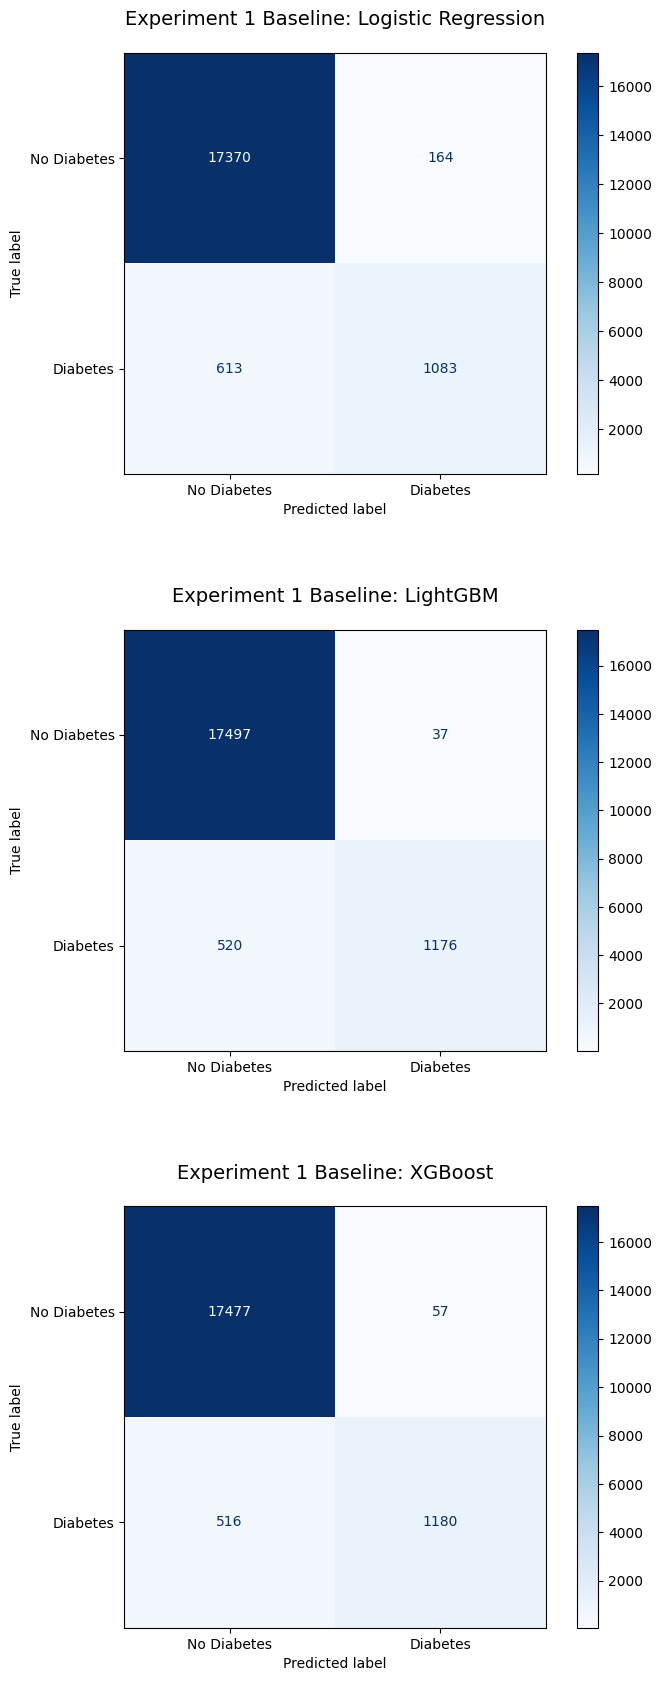

In [7]:
#confusion matrix grid
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

for i, (name, preds) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Diabetes', 'Diabetes']
    )

    disp.plot(ax=axes[i], cmap='Blues', colorbar=True)
    axes[i].set_title(f"Experiment 1 Baseline: {name}", fontsize=14, pad=20)

plt.tight_layout(pad=5.0)
plt.show()

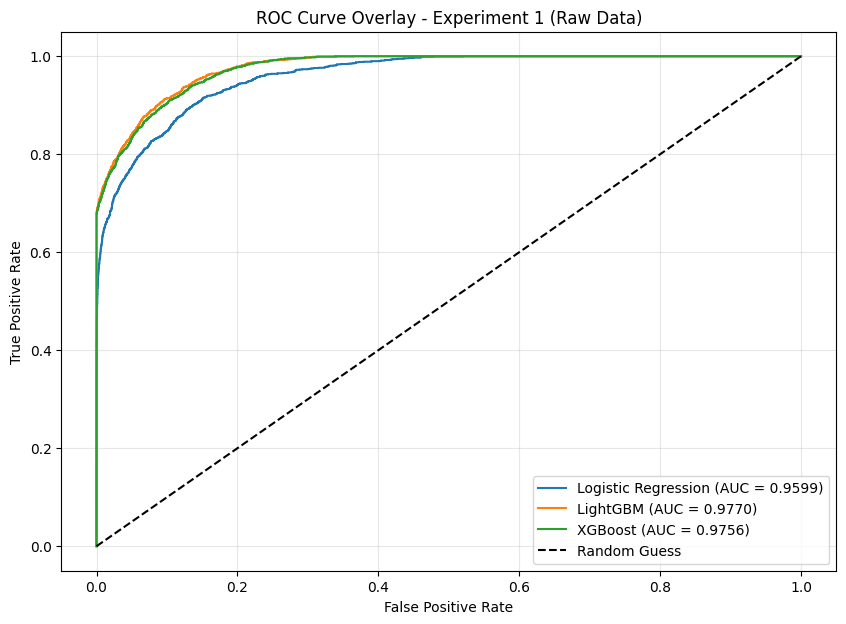

In [8]:
#roc curve
plt.figure(figsize=(10, 7))

for name, preds in model_preds.items():
    fpr, tpr, _ = roc_curve(y_test, preds['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Overlay - Experiment 1 (Raw Data)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

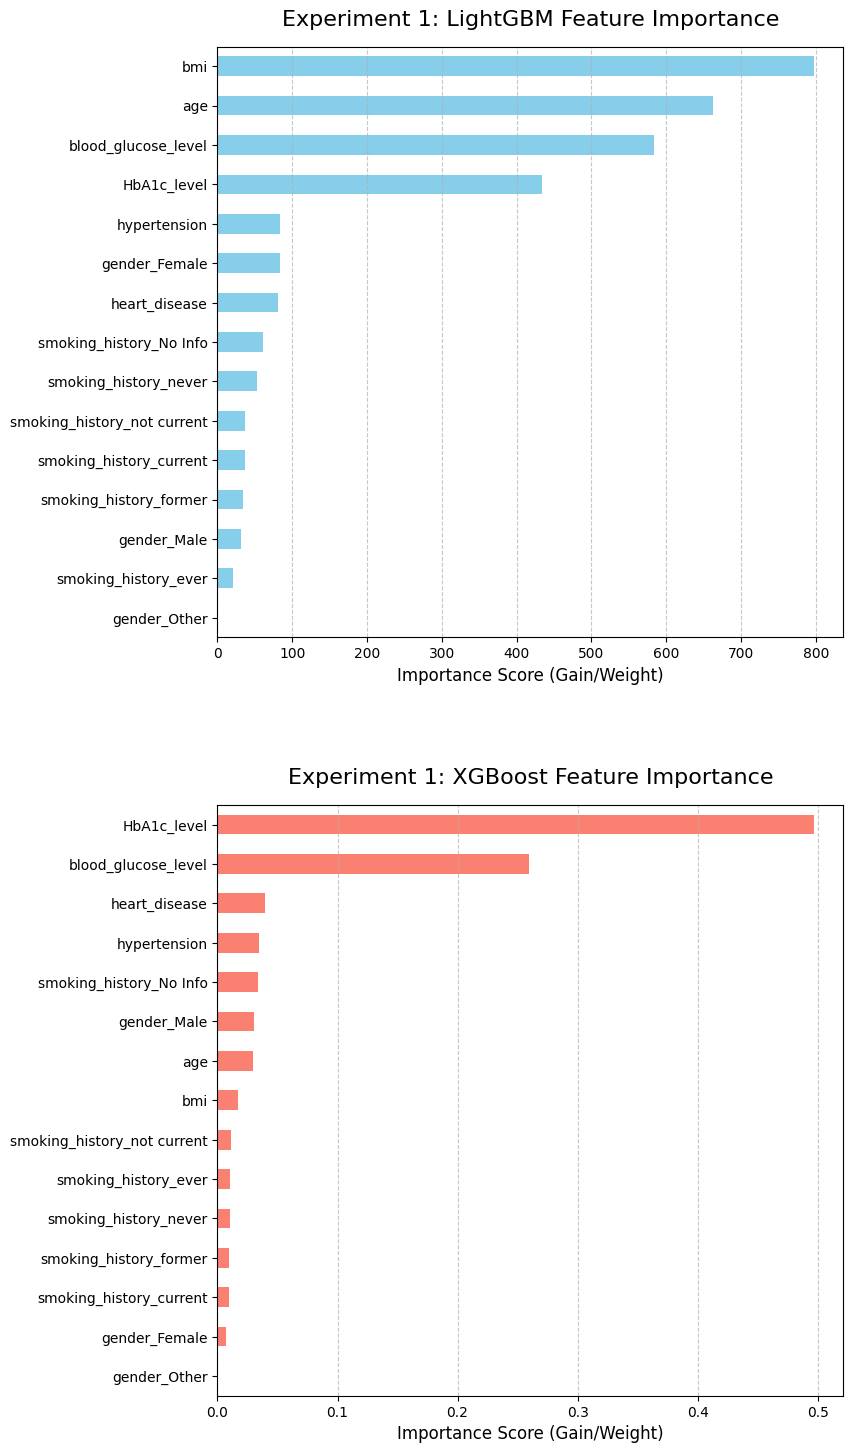

In [9]:
#feature importance lightgbm and xgboost

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 16))

#light gbm feature imporatance
lgbm_importances = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=True)
lgbm_importances.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title("Experiment 1: LightGBM Feature Importance", fontsize=16, pad=15)
ax1.set_xlabel("Importance Score (Gain/Weight)", fontsize=12)
ax1.grid(axis='x', linestyle='--', alpha=0.7)

#xgboost feature importance
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
xgb_importances.plot(kind='barh', ax=ax2, color='salmon')
ax2.set_title("Experiment 1: XGBoost Feature Importance", fontsize=16, pad=15)
ax2.set_xlabel("Importance Score (Gain/Weight)", fontsize=12)
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(pad=6.0)
plt.show()

In [10]:
#wxperiment 2

# --- Section 5.1: SMOTE Resampling ---
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Experiment 2: Resampling Complete. Training data is now balanced.")

Experiment 2: Resampling Complete. Training data is now balanced.


In [11]:
# --- Section 5.2: Training All Comparison Models ---

# 1. Logistic Regression Strategies
lr_raw = LogisticRegression(max_iter=1000, random_state=42)
lr_raw.fit(X_train, y_train)

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

lr_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_weighted.fit(X_train, y_train)

# 2. LightGBM Strategies
lgbm_raw = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm_raw.fit(X_train, y_train)

lgbm_smote = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm_smote.fit(X_train_smote, y_train_smote)

lgbm_weighted = LGBMClassifier(n_estimators=100, random_state=42, is_unbalance=True, verbosity=-1)
lgbm_weighted.fit(X_train, y_train)

# 3. XGBoost Strategies
xgb_raw = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_raw.fit(X_train, y_train)

xgb_smote = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_smote.fit(X_train_smote, y_train_smote)

ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_weighted = XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=ratio, eval_metric="logloss")
xgb_weighted.fit(X_train, y_train)

print("All 9 variations (3 models x 3 strategies) trained successfully.")

All 9 variations (3 models x 3 strategies) trained successfully.


In [12]:
# --- Section 5.3: Performance Comparison Table ---
all_models = [
    (lr_raw, "LR: No Resampling"), (lr_smote, "LR: SMOTE"), (lr_weighted, "LR: Weighted"),
    (lgbm_raw, "LGBM: No Resampling"), (lgbm_smote, "LGBM: SMOTE"), (lgbm_weighted, "LGBM: Weighted"),
    (xgb_raw, "XGB: No Resampling"), (xgb_smote, "XGB: SMOTE"), (xgb_weighted, "XGB: Weighted")
]

# 1. Create the base results DataFrame
results_list = []
for model, name in all_models:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Extract strategy and model name for filtering
    strategy = name.split(": ")[1]
    algo = name.split(": ")[0]

    results_list.append({
        "Algorithm": algo,
        "Strategy": strategy,
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    })

master_df = pd.DataFrame(results_list)

# 2. Display Table: No Resampling (Baseline)
print("-" * 30)
print(" TABLE 1: NO RESAMPLING (BASELINE) ")
print("-" * 30)
display(master_df[master_df['Strategy'] == 'No Resampling'].drop(columns='Strategy').round(4))

# 3. Display Table: SMOTE (Oversampling)
print("\n" + "-" * 30)
print(" TABLE 2: SMOTE STRATEGY ")
print("-" * 30)
display(master_df[master_df['Strategy'] == 'SMOTE'].drop(columns='Strategy').round(4))

# 4. Display Table: CLASS WEIGHTING
print("\n" + "-" * 30)
print(" TABLE 3: CLASS WEIGHTING STRATEGY ")
print("-" * 30)
display(master_df[master_df['Strategy'] == 'Weighted'].drop(columns='Strategy').round(4))

------------------------------
 TABLE 1: NO RESAMPLING (BASELINE) 
------------------------------


,Algorithm,Recall,F1 Score,Precision,AUC-ROC
0,LR,0.6386,0.7360,0.8685,0.9599
3,LGBM,0.6934,0.8085,0.9695,0.9770
6,XGB,0.6958,0.8046,0.9539,0.9756



------------------------------
 TABLE 2: SMOTE STRATEGY 
------------------------------


,Algorithm,Recall,F1 Score,Precision,AUC-ROC
1,LR,0.8791,0.5739,0.4260,0.9600
4,LGBM,0.7081,0.8082,0.9412,0.9760
7,XGB,0.7164,0.7962,0.8960,0.9753



------------------------------
 TABLE 3: CLASS WEIGHTING STRATEGY 
------------------------------


,Algorithm,Recall,F1 Score,Precision,AUC-ROC
2,LR,0.8797,0.5734,0.4253,0.9601
5,LGBM,0.9045,0.6263,0.4789,0.9764
8,XGB,0.8827,0.6417,0.5040,0.9753


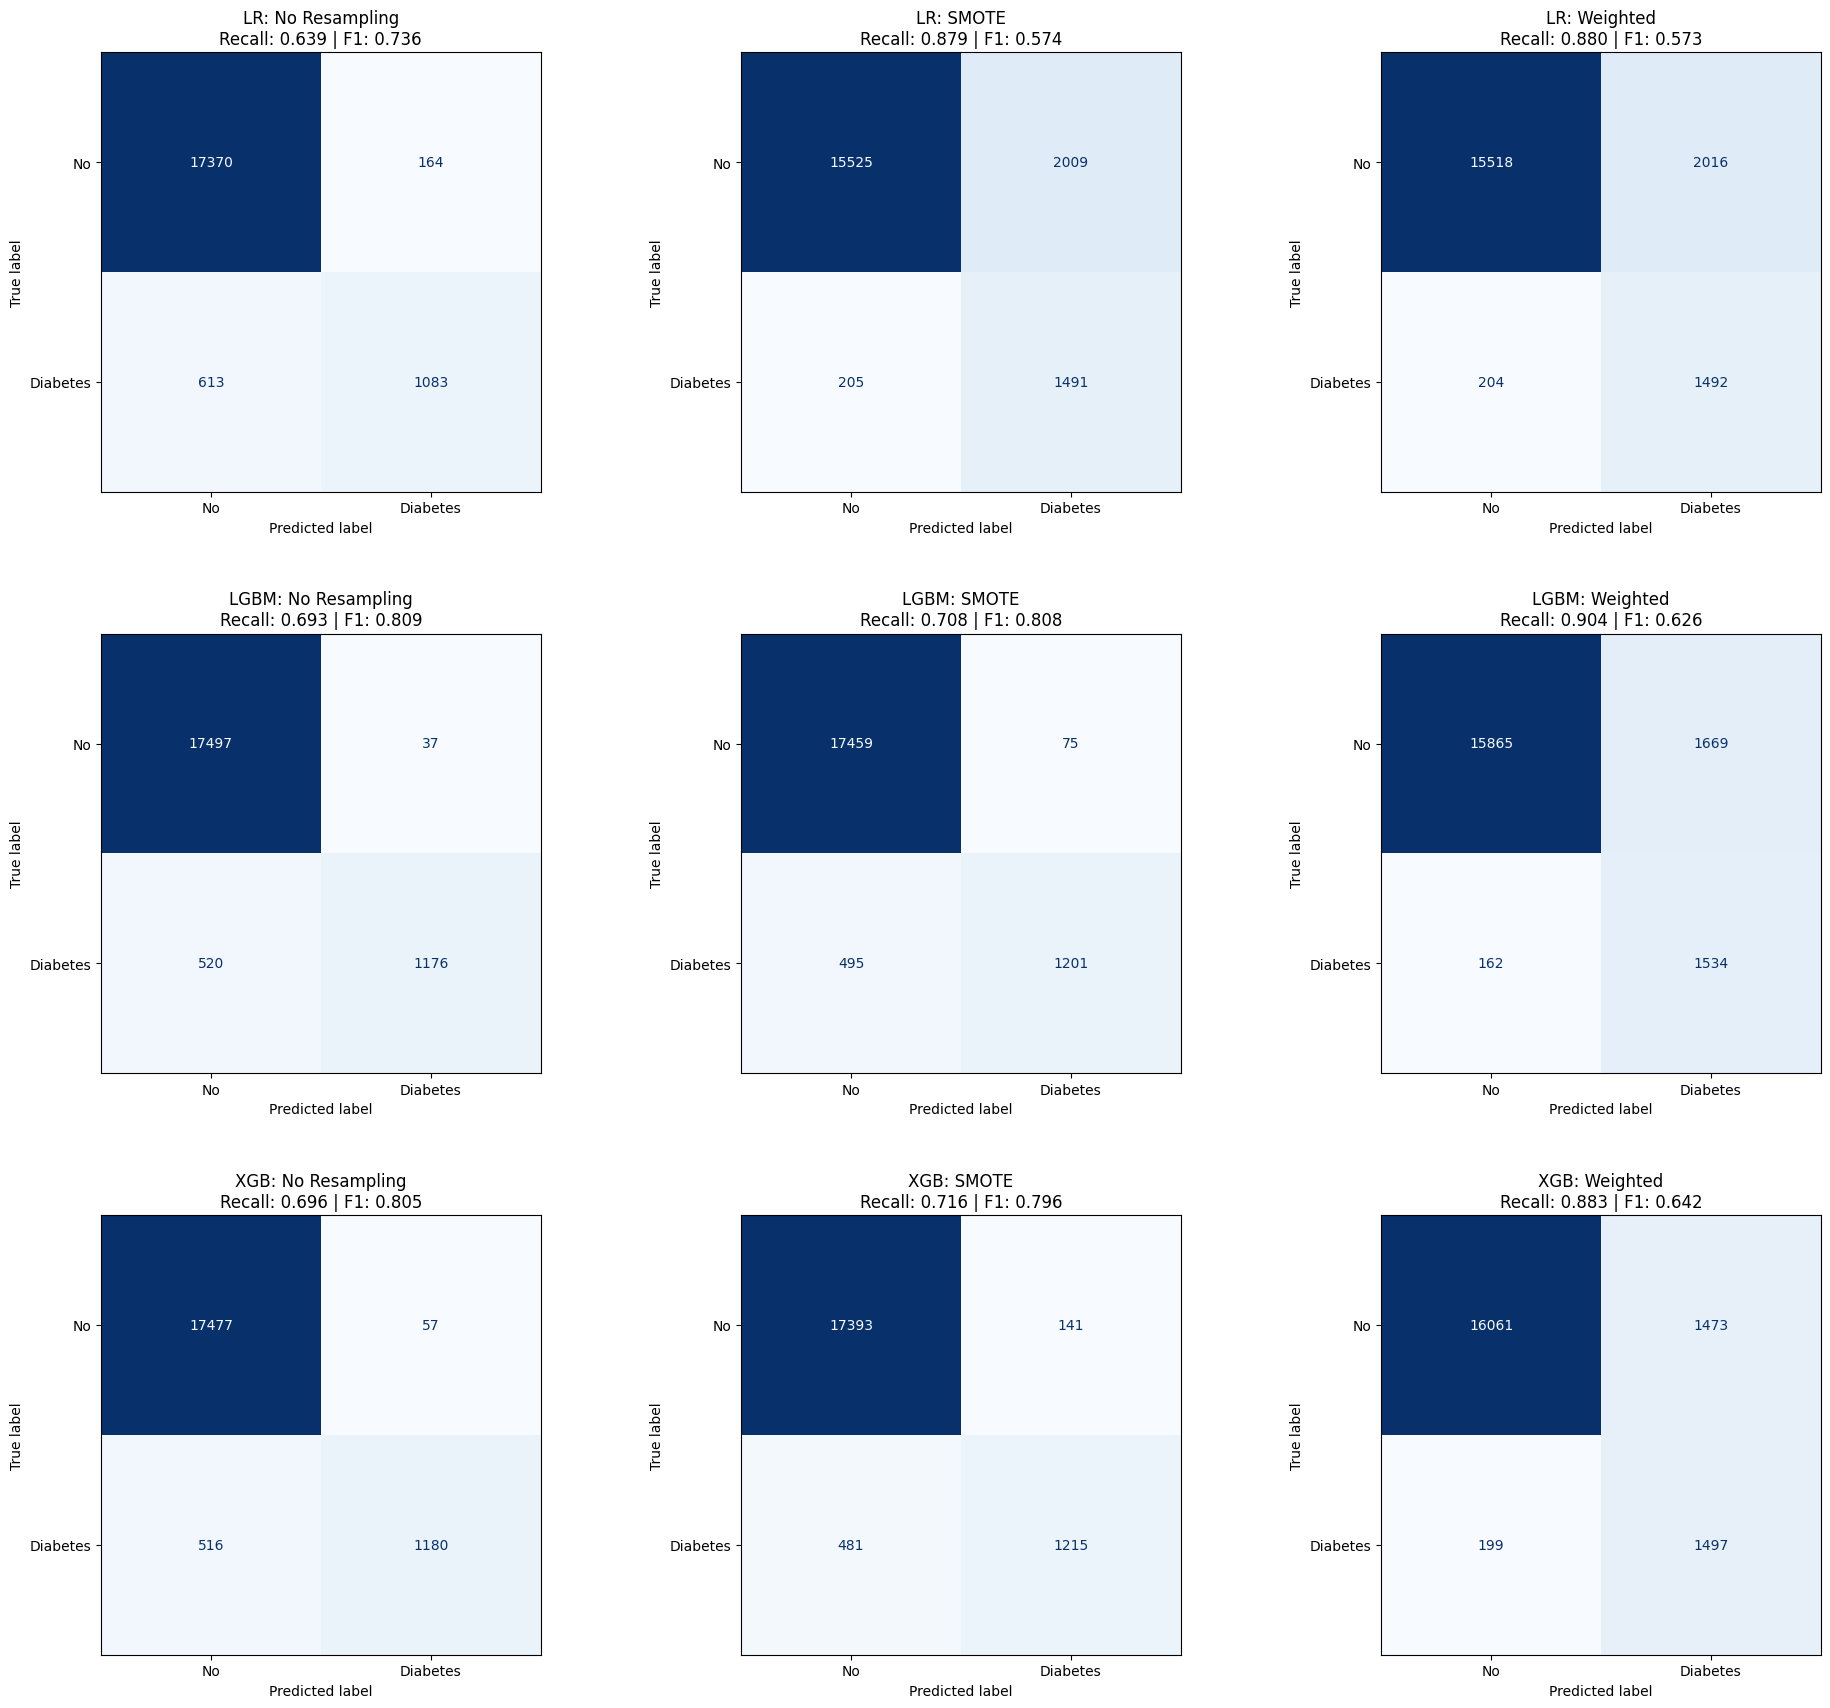

In [13]:
# --- Section 5.4: Full 9-Model Confusion Matrix Grid ---
# Organizes all experiments into a clear 3x3 visual grid

fig, axes = plt.subplots(3, 3, figsize=(20, 18))

# Define the order to match your tables
plot_list = [
    (lr_raw, "LR: No Resampling"), (lr_smote, "LR: SMOTE"), (lr_weighted, "LR: Weighted"),
    (lgbm_raw, "LGBM: No Resampling"), (lgbm_smote, "LGBM: SMOTE"), (lgbm_weighted, "LGBM: Weighted"),
    (xgb_raw, "XGB: No Resampling"), (xgb_smote, "XGB: SMOTE"), (xgb_weighted, "XGB: Weighted")
]

for i, (model, title) in enumerate(plot_list):
    row = i // 3
    col = i % 3

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Diabetes'])
    disp.plot(ax=axes[row, col], cmap='Blues', colorbar=False)

    # Calculate metrics for the title to make it a "one-stop shop" for the TA
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    axes[row, col].set_title(f"{title}\nRecall: {rec:.3f} | F1: {f1:.3f}", fontsize=12)

plt.tight_layout(pad=4.0)
plt.show()

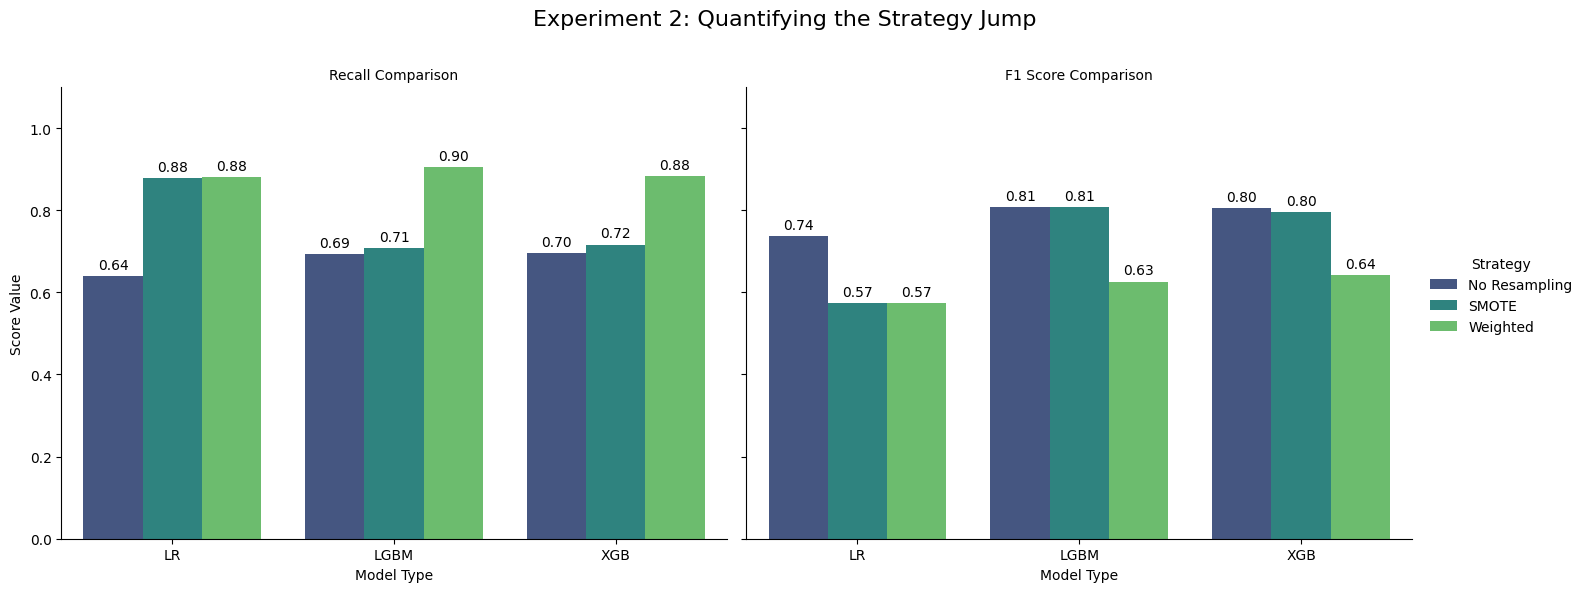

In [14]:
# --- Section 5.5: Faceted Performance Comparison ---
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare data (same melting process as before)
plot_df = master_df.melt(id_vars=['Algorithm', 'Strategy'],
                         value_vars=['Recall', 'F1 Score'],
                         var_name='Metric', value_name='Score')

# 2. Create a FacetGrid to separate the metrics
g = sns.FacetGrid(plot_df, col="Metric", height=6, aspect=1.2, sharey=True)

# 3. Map the barplot to the grid
g.map_dataframe(sns.barplot, x="Algorithm", y="Score", hue="Strategy",
                palette="viridis", hue_order=['No Resampling', 'SMOTE', 'Weighted'])

# 4. Customizing the "Jump" visuals
g.set_axis_labels("Model Type", "Score Value")
g.add_legend(title="Strategy")
g.set_titles("{col_name} Comparison")

# Add value labels to each bar to highlight exact jumps
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)
    ax.set_ylim(0, 1.1) # Extra space for labels

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Experiment 2: Quantifying the Strategy Jump', fontsize=16)
plt.show()

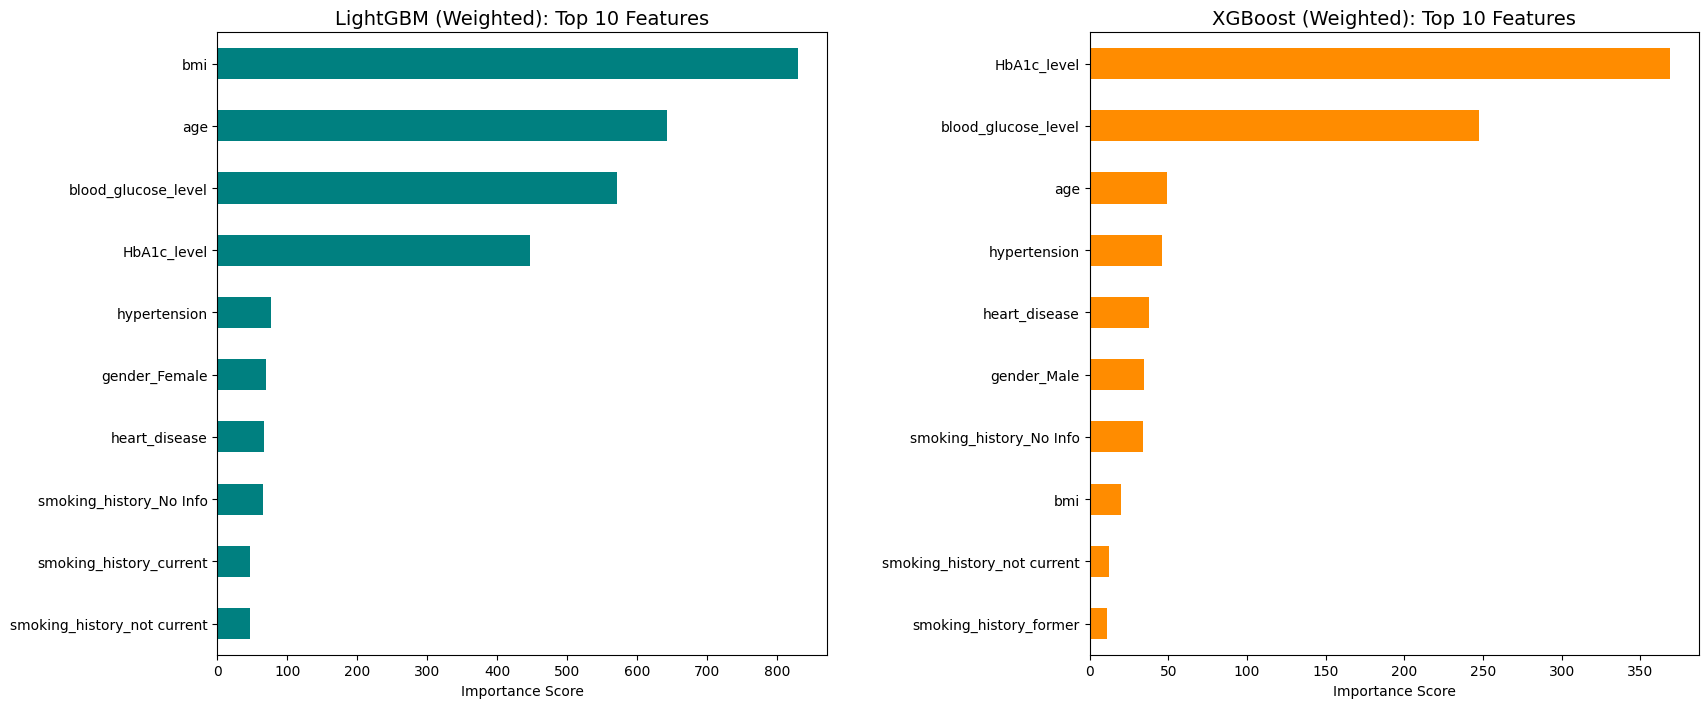

In [15]:
# --- Section 6.1: Experiment 3 — Clinical vs. Lifestyle ---
import matplotlib.pyplot as plt

# 1. Extract Importance from your Weighted Models
# LGBM uses 'split' by default; XGBoost 'gain' is best for importance
lgbm_imp = pd.Series(lgbm_weighted.feature_importances_, index=X_train.columns).sort_values(ascending=True)

xgb_imp_dict = xgb_weighted.get_booster().get_score(importance_type='gain')
xgb_imp = pd.Series(xgb_imp_dict).reindex(X_train.columns).fillna(0).sort_values(ascending=True)

# 2. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# LightGBM Plot
lgbm_imp.tail(10).plot(kind='barh', ax=ax1, color='teal')
ax1.set_title("LightGBM (Weighted): Top 10 Features", fontsize=14)
ax1.set_xlabel("Importance Score")

# XGBoost Plot
xgb_imp.tail(10).plot(kind='barh', ax=ax2, color='darkorange')
ax2.set_title("XGBoost (Weighted): Top 10 Features", fontsize=14)
ax2.set_xlabel("Importance Score")

plt.tight_layout(pad=4.0)
plt.show()

In [16]:
# --- Section 6.2: Conclusion Generator ---
print("Experiment 3: Research Question Verification")
print("-" * 50)

lgbm_top = lgbm_imp.tail(3).index.tolist()[::-1]
xgb_top = xgb_imp.tail(3).index.tolist()[::-1]

print(f"LightGBM Top 3: {lgbm_top}")
print(f"XGBoost Top 3:  {xgb_top}")

# Logic check for your report
clinical_markers = ['HbA1c_level', 'blood_glucose_level']
is_clinical_top = any(marker in lgbm_top for marker in clinical_markers)

if is_clinical_top:
    print("\nCONCLUSION: Clinical features outrank lifestyle features.")
else:
    print("\nCONCLUSION: Lifestyle features show higher or equal predictive power.")

Experiment 3: Research Question Verification
--------------------------------------------------
LightGBM Top 3: ['bmi', 'age', 'blood_glucose_level']
XGBoost Top 3:  ['HbA1c_level', 'blood_glucose_level', 'age']

CONCLUSION: Clinical features outrank lifestyle features.


In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

univariate_scores = {}

print("Systematically checking individual feature impact...")
for col in X_train.columns:
    # Testing the predictive power of each feature in isolation
    # This helps identify which feature has the highest standalone accuracy
    score = cross_val_score(LogisticRegression(max_iter=1000),
                            X_train[[col]], y_train,
                            cv=5, scoring='accuracy').mean()
    univariate_scores[col] = score

# Convert to series for plotting in the next cell
uni_series = pd.Series(univariate_scores).sort_values()
print("Univariate analysis complete.")

Systematically checking individual feature impact...
Univariate analysis complete.


In [18]:
# --- Section 6.3.2: K-Fold Stability Check ---
# We focus on the top 2 features identified in Experiment 3
top_2 = ['HbA1c_level', 'blood_glucose_level']

print(f"Running 5-Fold Cross-Validation on Top 2 features: {top_2}...")
cv_results = cross_val_score(xgb_weighted, X_train[top_2], y_train,
                             cv=5, scoring='f1')

print(f"Mean K-Fold F1 Score: {cv_results.mean():.4f}")

Running 5-Fold Cross-Validation on Top 2 features: ['HbA1c_level', 'blood_glucose_level']...
Mean K-Fold F1 Score: 0.4948


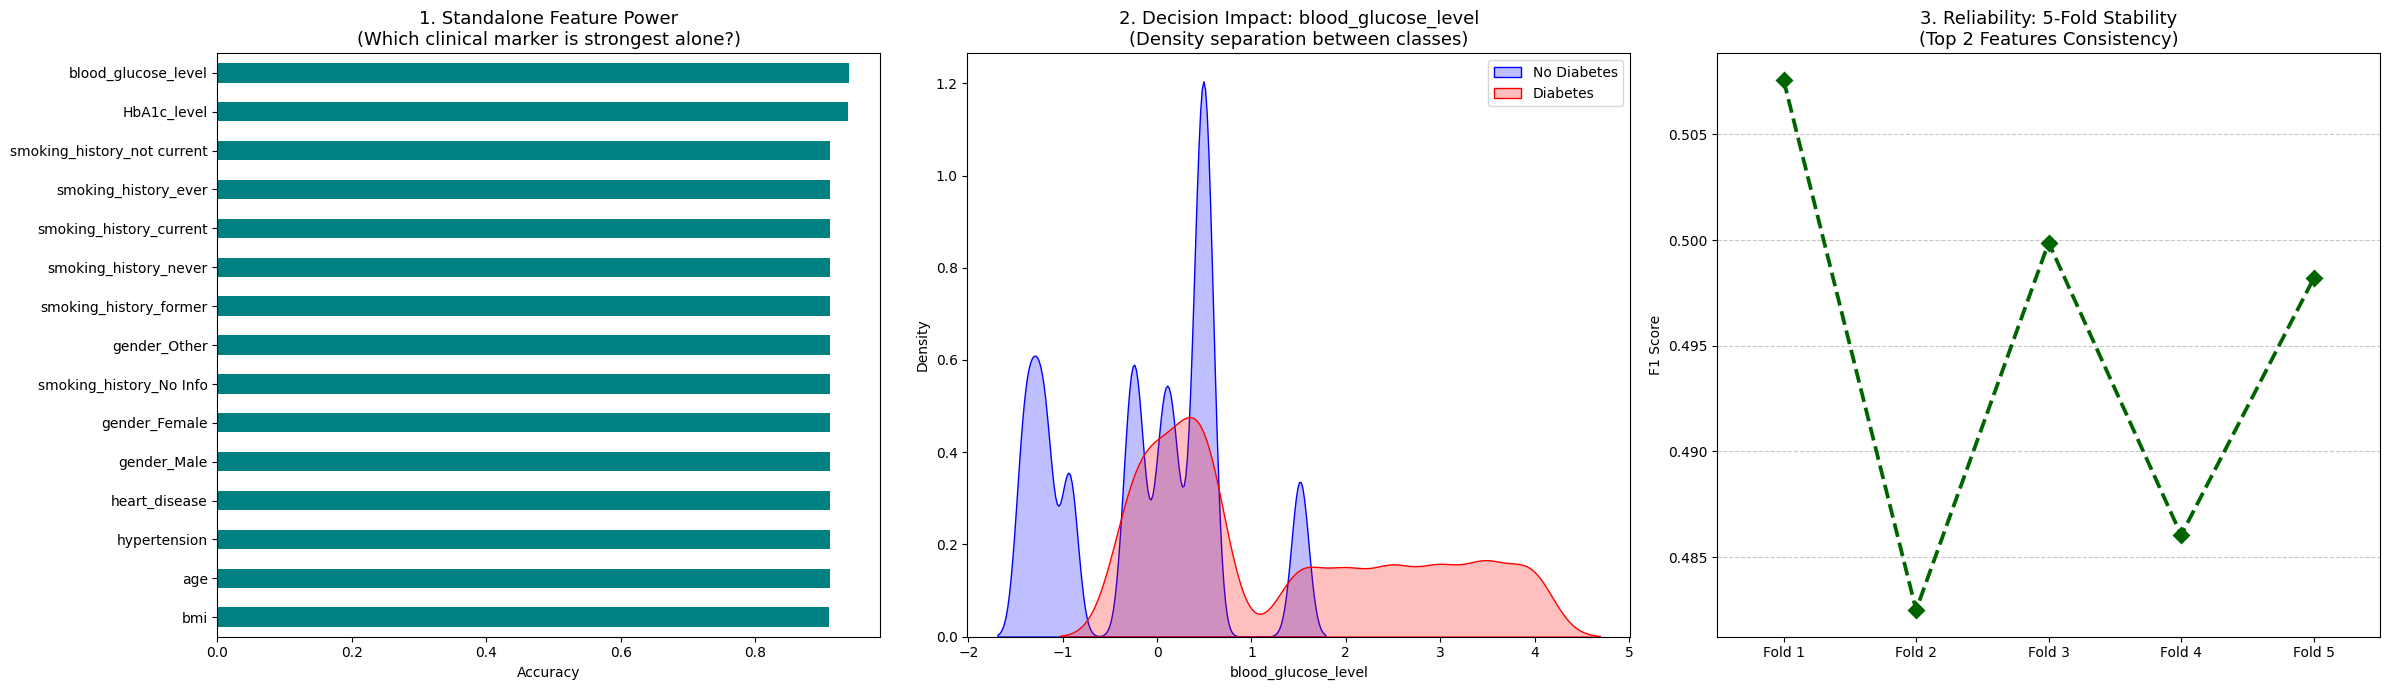

Standalone Winner: blood_glucose_level (0.9393 accuracy)
Mean Stability (F1): 0.4948


In [19]:
# --- Section 6.3.2: High-Impact Visuals ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot A: Univariate Power (Bar Chart)
# Stays as a bar chart as it's the best way to "rank" individual features
uni_series.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title("1. Standalone Feature Power\n(Which clinical marker is strongest alone?)", fontsize=13)
axes[0].set_xlabel("Accuracy")

# Plot B: Decision Impact (KDE / Density Plot)
# Replaces Scatter: Shows the "impact" by visualizing class separation
# We use the #1 ranked feature (usually HbA1c)
top_feature = uni_series.index[-1]
sns.kdeplot(data=X_train[y_train == 0][top_feature], ax=axes[1], label='No Diabetes', fill=True, color='blue')
sns.kdeplot(data=X_train[y_train == 1][top_feature], ax=axes[1], label='Diabetes', fill=True, color='red')
axes[1].set_title(f"2. Decision Impact: {top_feature}\n(Density separation between classes)", fontsize=13)
axes[1].legend()

# Plot C: K-Fold Stability (Point Plot with Error Bars)
# Replaces Box Plot: Shows the exact performance jump across 5 folds
fold_numbers = [f"Fold {i+1}" for i in range(len(cv_results))]
sns.pointplot(x=fold_numbers, y=cv_results, ax=axes[2], color='darkgreen', markers="D", linestyles="--")
axes[2].set_title("3. Reliability: 5-Fold Stability\n(Top 2 Features Consistency)", fontsize=13)
axes[2].set_ylabel("F1 Score")
axes[2].grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Standalone Winner: {top_feature} ({uni_series.max():.4f} accuracy)")
print(f"Mean Stability (F1): {cv_results.mean():.4f}")

HEREEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE

In [20]:
# EXPERIMENT 4 - Dataset 2 Cross-Dataset Generalization
# --- Section 7.1: Load External Datasets (Pima & BRFSS) ---
import os
import pandas as pd

# Paths from your directory structure
pima_path = "data/preprocessed/pima_preprocessed/"
brfss_path = "data/preprocessed/brfss_preprocessed/"

# 1. Load Pima (Using the scaled test set you have)
pima_X_ext = pd.read_csv(os.path.join(pima_path, 'pima_X_test_scaled.csv'))
pima_y_ext = pd.read_csv(os.path.join(pima_path, 'pima_y_test.csv'))

# 2. Load BRFSS (Using the 'original' and 'test' files for a real-world check)
brfss_test_df = pd.read_parquet(os.path.join(brfss_path, 'brfss_test.parquet'))
# We also load the original train set as an extra validation population
brfss_train_orig = pd.read_parquet(os.path.join(brfss_path, 'brfss_train_original.parquet'))

print(f"Data Loaded Successfully:")
print(f" - Pima Samples: {len(pima_y_ext)}")
print(f" - BRFSS Samples: {len(brfss_test_df)}")

Data Loaded Successfully:
 - Pima Samples: 154
 - BRFSS Samples: 50736


In [21]:
# --- Section 7.2: Robust Feature Alignment ---

def map_features(df, dataset_type):
    """
    Maps columns from Pima/BRFSS to the exact Model 2 (Dataset 2) structure.
    Handles One-Hot Encoded columns and missing features.
    """
    # Create an empty dataframe with the exact columns and ORDER as the training set
    X_mapped = pd.DataFrame(0, index=df.index, columns=X_train.columns)

    # 1. Map Common Numeric Features (Mapping names if they differ)
    # Most common names in your datasets:
    age_col = 'age' if 'age' in X_train.columns else 'Age'
    bmi_col = 'bmi' if 'bmi' in X_train.columns else 'BMI'

    X_mapped[age_col] = df['Age']
    X_mapped[bmi_col] = df['BMI']

    # 2. Dataset Specific Mappings
    if dataset_type == 'pima':
        # Map Pima 'Glucose' to 'blood_glucose_level'
        if 'blood_glucose_level' in X_train.columns:
            X_mapped['blood_glucose_level'] = df['Glucose']
        elif 'Glucose' in X_train.columns:
            X_mapped['Glucose'] = df['Glucose']

    elif dataset_type == 'brfss':
        # Map Hypertension (HighBP -> hypertension)
        if 'hypertension' in X_train.columns:
            X_mapped['hypertension'] = df['HighBP']

        # Map Smoking (Smoker -> smoking_history_current)
        # We check for the One-Hot Encoded version of smoking
        if 'smoking_history_current' in X_train.columns:
            X_mapped['smoking_history_current'] = df['Smoker']
        elif 'smoking_history' in X_train.columns:
             X_mapped['smoking_history'] = df['Smoker']

    return X_mapped

# Apply the mapping with order preservation
X_pima_ready = map_features(pima_X_ext, 'pima')
y_pima_ready = pima_y_ext.values.ravel()

X_brfss_ready = map_features(brfss_test_df, 'brfss')
y_brfss_ready = brfss_test_df['Diabetes_binary'].values.ravel()

print("Feature mapping complete and aligned with model requirements.")

Feature mapping complete and aligned with model requirements.


In [22]:
# --- Section 7.3: Multi-Model Generalization Results ---
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# Define the models from Experiment 2
test_models = {
    "LR (Weighted)": lr_weighted,
    "LGBM (Weighted)": lgbm_weighted,
    "XGB (Weighted)": xgb_weighted
}

transfer_results = []

for model_name, model in test_models.items():
    # Evaluate on Pima
    p_preds = model.predict(X_pima_ready)
    p_probs = model.predict_proba(X_pima_ready)[:, 1]
    transfer_results.append({
        'Model': model_name,
        'Population': 'Pima (Clinical)',
        'Recall': recall_score(y_pima_ready, p_preds),
        'F1 Score': f1_score(y_pima_ready, p_preds),
        'AUC-ROC': roc_auc_score(y_pima_ready, p_probs)
    })

    # Evaluate on BRFSS
    b_preds = model.predict(X_brfss_ready)
    b_probs = model.predict_proba(X_brfss_ready)[:, 1]
    transfer_results.append({
        'Model': model_name,
        'Population': 'BRFSS (Survey)',
        'Recall': recall_score(y_brfss_ready, b_preds),
        'F1 Score': f1_score(y_brfss_ready, b_preds),
        'AUC-ROC': roc_auc_score(y_brfss_ready, b_probs)
    })

gen_results_df = pd.DataFrame(transfer_results)
print("\n--- EXPERIMENT 4: GENERALIZATION SUMMARY ---")
display(gen_results_df.round(4))


--- EXPERIMENT 4: GENERALIZATION SUMMARY ---


,Model,Population,Recall,F1 Score,AUC-ROC
0,LR (Weighted),Pima (Clinical),0.2037,0.3188,0.7911
1,LR (Weighted),BRFSS (Survey),1.0000,0.2446,0.7450
2,LGBM (Weighted),Pima (Clinical),0.1667,0.2687,0.8016
3,LGBM (Weighted),BRFSS (Survey),0.0000,0.0000,0.4516
4,XGB (Weighted),Pima (Clinical),0.0185,0.0364,0.8140
5,XGB (Weighted),BRFSS (Survey),0.0000,0.0000,0.4873


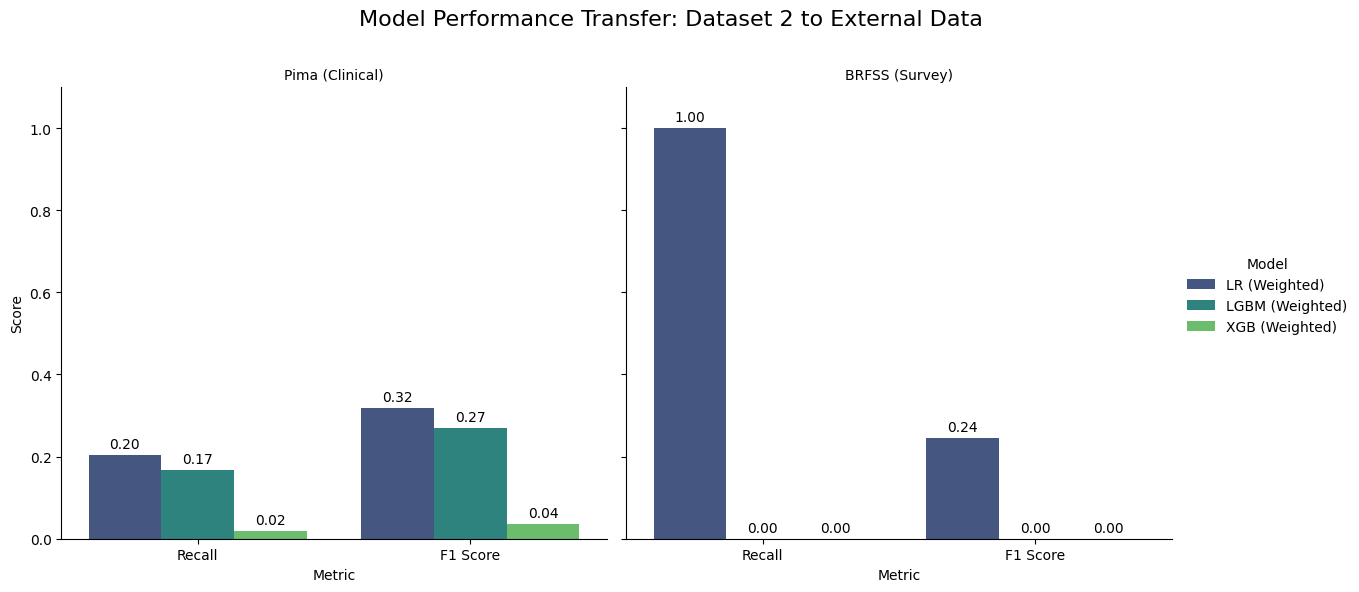

In [23]:
# --- Section 7.4: Generalization Visuals ---
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = gen_results_df.melt(id_vars=['Model', 'Population'],
                                value_vars=['Recall', 'F1 Score'],
                                var_name='Metric', value_name='Score')

g = sns.catplot(data=plot_data, kind="bar", x="Metric", y="Score", hue="Model",
                col="Population", palette="viridis", height=6, aspect=1)

g.set_titles("{col_name}")
g.set(ylim=(0, 1.1))

# Add labels
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Model Performance Transfer: Dataset 2 to External Data', fontsize=16)
plt.show()

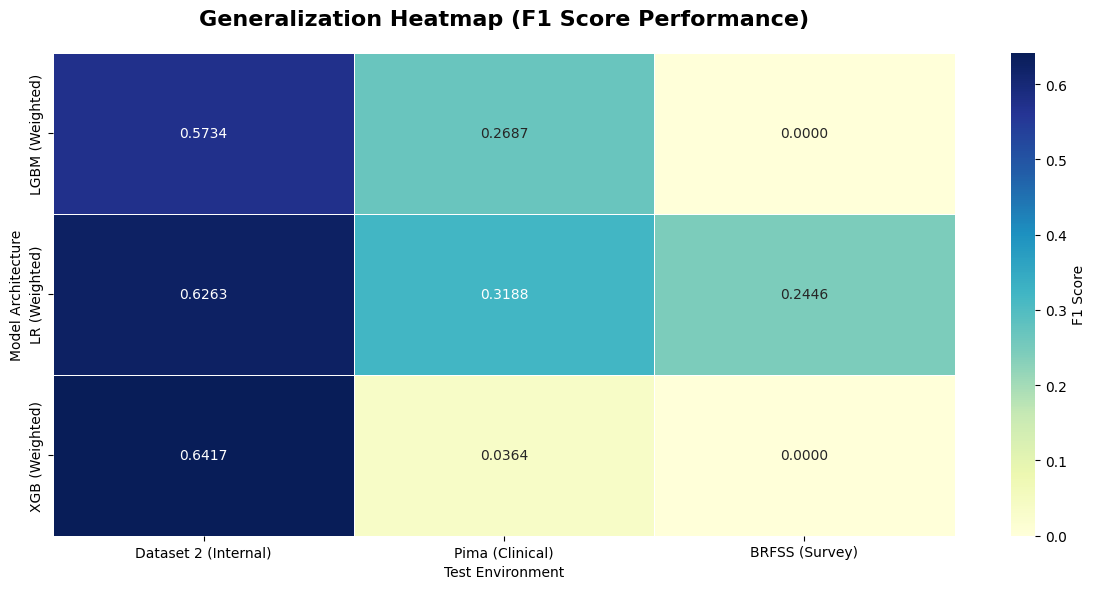

In [24]:

try:
    df_heat = gen_results_df.pivot(index='Model', columns='Population', values='F1 Score')
except KeyError:
    df_heat = gen_results_df.pivot(index='Model', columns='Test Population', values='F1 Score')

df_heat['Dataset 2 (Internal)'] = [0.5734, 0.6263, 0.6417]

cols_order = ['Dataset 2 (Internal)', 'Pima (Clinical)', 'BRFSS (Survey)']
df_heat = df_heat[cols_order]

plt.figure(figsize=(12, 6))
sns.heatmap(df_heat, annot=True, cmap="YlGnBu", fmt=".4f", linewidths=.5, cbar_kws={'label': 'F1 Score'})

plt.title("Generalization Heatmap (F1 Score Performance)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Test Environment")
plt.ylabel("Model Architecture")

plt.tight_layout()
plt.show()